In [1]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda") # Google Colab GPU
elif torch.backends.mps.is_available():
    device = torch.device("mps") # Mac GPU
else:
    device = torch.device("cpu") # CPU
    
print(device)

mps


# Importing Data

In [2]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from datasets import load_dataset

def import_test_variant(path):
    """
    Loads a test set variant based on a path.

    Args:
        path (str): The path of the directory where the test images are stored.

    Returns:
        torchvision.datasets.ImageFolder: A test variant dataset.
    """

    return datasets.ImageFolder(root=path, transform=test_transform)

def transform_train(huggingface):
    """
    Loads a Hugging Face dataset.

    Args:
        huggingface (dict): Images from Hugging Face.

    Returns:
        dict: The updated dictionary with a new 'pixel_values' key containing processed Tensors.
    """

    huggingface["pixel_values"] = [train_transform(image.convert("RGB")) for image in huggingface["image"]]
    return huggingface

def collate(images):
    """
    Batches Hugging Face dictionary items into Tensors.

    Args:
        images (list): A list of dictionary items retrieved from the dataset.

    Returns:
        tuple: A pair containing (pixel_values_tensor, labels_tensor).
    """

    pixel_values = torch.stack([image["pixel_values"] for image in images])
    labels = torch.tensor([image["label"] for image in images])
    return pixel_values, labels

# Main dataset
food = load_dataset("ethz/food101")

# Training set
train = food['train'].with_transform(transform_train)
# DO NOT USE food['validation'] for test data, use test_clean instead

# Used to transform training data
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224), # Random crop and resize to 224x224 px, for robustness
    transforms.RandomHorizontalFlip(), # Random 50% flip, for robustness
    transforms.ToTensor(), # Convert image (0-255) into 0.0-1.0
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Standard values
])

# Used to transform test data
test_transform = transforms.Compose([
    transforms.Resize(256), # Bigger than 224 so crop ensures food fills image
    transforms.CenterCrop(224), # Same size as the train_transform crop
    transforms.ToTensor(), # Convert image (0-255) into 0.0-1.0
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Standard values
])

test_directory = "test_splits"
model_directory = "models"
evaluation_directory = "evaluations" 

# Test variant paths in Google Drive
clean_path = f'{test_directory}/clean'
blur_little_path = f'{test_directory}/blur_little'
blur_medium_path = f'{test_directory}/blur_medium'
downsampled_path = f'{test_directory}/downsampled'
masked_path = f'{test_directory}/masked'
noise_rotation_path = f'{test_directory}/noise_rotation'

# Final test variants
test_clean = import_test_variant(clean_path)
test_blur_little = import_test_variant(blur_little_path)
test_blur_medium = import_test_variant(blur_medium_path)
test_downsampled = import_test_variant(downsampled_path)
test_masked = import_test_variant(masked_path)
test_noise_rotation = import_test_variant(noise_rotation_path)

test_sets = {
    "Clean": test_clean,
    "Blur_Little": test_blur_little,
    "Blur_Medium": test_blur_medium,
    "Downsampled": test_downsampled,
    "Masked": test_masked,
    "Noise_Rotation": test_noise_rotation
}

print("\nData import complete")


Data import complete


# Exploration

In [3]:
print("DATASET SIZES")
print()
print(f"Training: {len(train)}")
print(f"Test (Clean): {len(test_clean)}")
print()
print(f"Test (Blur Little): {len(test_blur_little)}")
print(f"Test (Blur Medium): {len(test_blur_medium)}")
print(f"Test (Downsampled): {len(test_downsampled)}")
print(f"Test (Masked): {len(test_masked)}")
print(f"Test (Noise Rotation): {len(test_noise_rotation)}")

DATASET SIZES

Training: 75750
Test (Clean): 25250

Test (Blur Little): 25250
Test (Blur Medium): 25250
Test (Downsampled): 25250
Test (Masked): 25250
Test (Noise Rotation): 25250


In [4]:
food_classes = test_clean.classes

for i in range(0, len(food_classes), 5):
    print(', '.join(food_classes[i : i+5]))

apple_pie, baby_back_ribs, baklava, beef_carpaccio, beef_tartare
beet_salad, beignets, bibimbap, bread_pudding, breakfast_burrito
bruschetta, caesar_salad, cannoli, caprese_salad, carrot_cake
ceviche, cheese_plate, cheesecake, chicken_curry, chicken_quesadilla
chicken_wings, chocolate_cake, chocolate_mousse, churros, clam_chowder
club_sandwich, crab_cakes, creme_brulee, croque_madame, cup_cakes
deviled_eggs, donuts, dumplings, edamame, eggs_benedict
escargots, falafel, filet_mignon, fish_and_chips, foie_gras
french_fries, french_onion_soup, french_toast, fried_calamari, fried_rice
frozen_yogurt, garlic_bread, gnocchi, greek_salad, grilled_cheese_sandwich
grilled_salmon, guacamole, gyoza, hamburger, hot_and_sour_soup
hot_dog, huevos_rancheros, hummus, ice_cream, lasagna
lobster_bisque, lobster_roll_sandwich, macaroni_and_cheese, macarons, miso_soup
mussels, nachos, omelette, onion_rings, oysters
pad_thai, paella, pancakes, panna_cotta, peking_duck
pho, pizza, pork_chop, poutine, prime_r

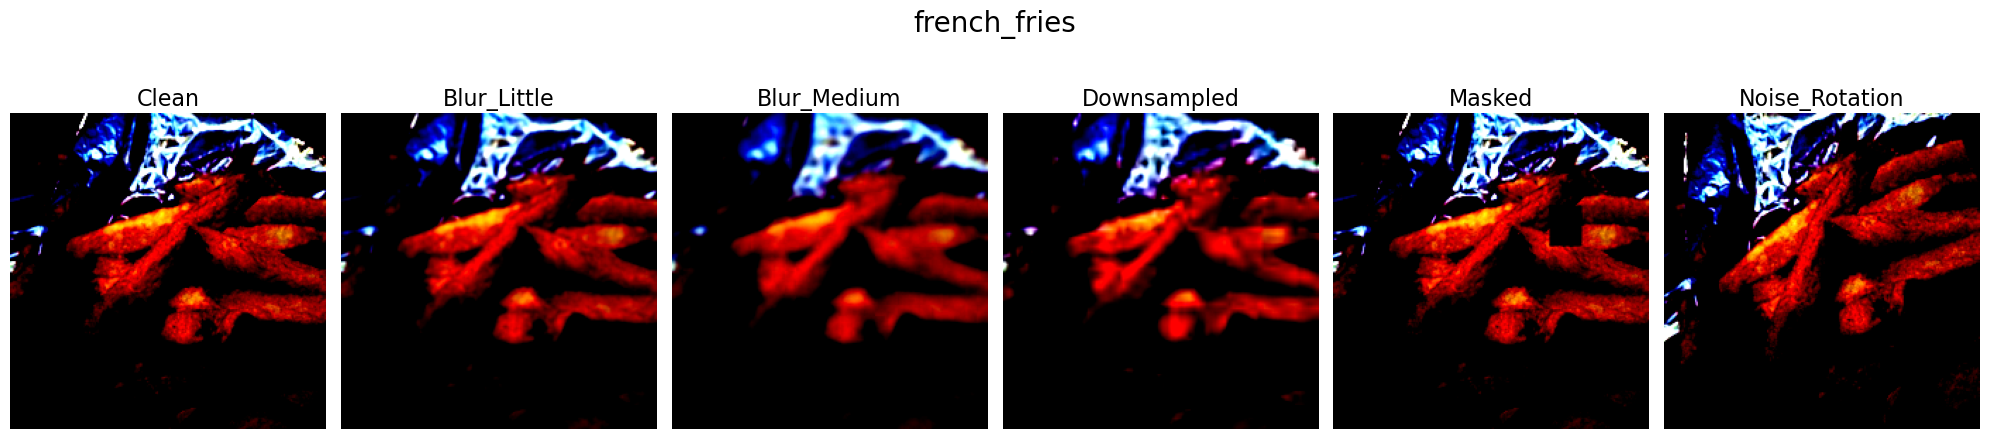

In [5]:
# This block of code shows all variants of a random test image (after applying transformer).

import matplotlib.pyplot as plt
import numpy as np
import random

# Getting random test index and the assocoiated class name
random_idx = random.randint(0, len(test_sets["Clean"]) - 1)
_, label_idx = test_sets["Clean"][random_idx]
class_name = test_sets["Clean"].classes[label_idx]

# Plotting
fig, axes = plt.subplots(1, len(test_sets), figsize=(20, 5))

for i, (name, test_set) in enumerate(test_sets.items()):

    # Tensor to image
    img_tensor, _ = test_set[random_idx]
    img = img_tensor.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)

    # Adding image for variant
    axes[i].imshow(img)
    axes[i].set_title(name, fontsize=16)
    axes[i].axis('off')

fig.suptitle(f"{class_name}", fontsize=20)
plt.tight_layout()
plt.show()

# Backbone

In [6]:
import torch.nn as nn
from torchvision import models

# Number of classes of food in the dataset
num_classes = len(food_classes)

# ResNet18
resnet = models.resnet18(weights='IMAGENET1K_V1')
# Adjust the output layer for the specific number of classes
num_ftrs_res = resnet.fc.in_features
resnet.fc = nn.Linear(num_ftrs_res, num_classes)

# EfficientNetV2-S
effnet = models.efficientnet_v2_s(weights='IMAGENET1K_V1')
# Adjust the output layer for the specific number of classes
num_ftrs_eff = effnet.classifier[1].in_features
effnet.classifier[1] = nn.Linear(num_ftrs_eff, num_classes)

# Linear Probing (Baseline)

In [7]:
import copy

def freeze_all_layers(model):
    """
    Freezes all weights and biases in the neural network.
    Used to establish baseline models.

    Args:
        model (torch.nn.Module): The model whose layers need to be frozen.

    Returns: None
    """

    for param in model.parameters():
        param.requires_grad = False

def get_linear_probe_model_resnet():

    resnet_model = copy.deepcopy(resnet)
    freeze_all_layers(resnet_model)
    resnet_model.fc.weight.requires_grad = True
    resnet_model.fc.bias.requires_grad = True

    return resnet_model

def get_linear_probe_model_effnet():

    effnet_model = copy.deepcopy(effnet)
    freeze_all_layers(effnet_model)
    effnet_model.classifier[1].weight.requires_grad = True
    effnet_model.classifier[1].bias.requires_grad = True

    return effnet_model

resnet_baseline = get_linear_probe_model_resnet()
effnet_baseline = get_linear_probe_model_effnet()

In [8]:
BATCH_SIZE = 512
train_loader = DataLoader(train, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate, num_workers=2)

def train_model(model, optimizer):
    """
    Trains a model. Iterates through 5 epoch. CrossEntropyLoss is used as the loss function.

    Args:
        model (torch.nn.Module): The model to be trained.
        optimizer (torch.optim.Optimizer): The algorithm responsible for updating model weights.

    Returns: None
    """

    model.to(device) # Transfer model to GPU/CPU

    n_epochs = 5 # Number of epochs
    loss_function = nn.CrossEntropyLoss() # Loss function

    for epoch in range(n_epochs):

        model.train() # Put model into training mode

        for data, target in train_loader:
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = loss_function(output, target)
            loss.backward()
            optimizer.step()

        print(f'Epoch {epoch+1}/{n_epochs}')

    print()

In [9]:
resnet_baseline_path = model_directory + '/resnet_baseline.pth'
effnet_baseline_path = model_directory + '/effnet_baseline.pth'

In [10]:
# Training baseline models with linear probing

# resnet_baseline.to(device) # resnet_baseline to GPU/CPU
# optimizer_resnet = torch.optim.Adam(resnet_baseline.parameters()) # Defining optimizer
# train_model(resnet_baseline, optimizer_resnet) # Training model
# torch.save(resnet_baseline.state_dict(), resnet_baseline_path) # Saving model

# effnet_baseline.to(device) # effnet_baseline to GPU/CPU
# optimizer_effnet = torch.optim.Adam(effnet_baseline.parameters()) # Defining optimizer
# train_model(effnet_baseline, optimizer_effnet) # Training model
# torch.save(effnet_baseline.state_dict(), effnet_baseline_path) # Saving model

# Model Evaluation

In [11]:
# Add any models you create
model_paths_to_evaluate = {
    "resnet_baseline": resnet_baseline_path,
    "effnet_baseline": effnet_baseline_path
}

In [12]:
import pandas as pd
import time
from thop import profile

def evaluate(model, dataset):
    """
    Evaluates the accuracy of a model on a dataset. This function iterates
    through the dataset in batches, performs a forward pass, and calculates the
    percentage of correctly classified images.

    Args:
        model (torch.nn.Module): The model to evaluate.
        dataset (torch.utils.data.Dataset): Dataset of images and labels.

    Returns:
        float: Accuracy between 0 and 1.
    """
    
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    correct = 0
    total = 0
    
    start_time = time.time()
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    end_time = time.time()
    
    avg_accuracy = correct / total
    evaluation_time = end_time - start_time
    inference_speed = evaluation_time / total # Time per image

    return avg_accuracy, inference_speed

# Determining accuracy for each model for each test variant
for model_name, model_path in model_paths_to_evaluate.items():

    model_evaluations = []

    match model_name:
        case "resnet_baseline":
            model = get_linear_probe_model_resnet()
        case "effnet_baseline":
            model = get_linear_probe_model_effnet()
        case _:
            raise ValueError(f"Unknown model: {model_name}")

    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    trainable_params = int(sum(p.numel() for p in model.parameters() if p.requires_grad))
    
    dummy_input = torch.randn(1, 3, 224, 224).to(device) # A fake image to test get flops
    macs, params = profile(model, inputs=(dummy_input,), verbose=False)
    flops = int(2*macs)

    print(f"Evaluating {model_name}:")
    print()
    print(f"\tTrainable Parameters: {trainable_params}")
    print(f"\tFLOPs: {flops}")
    print()

    for set_name, test_set in test_sets.items():

        accuracy, speed = evaluate(model, test_set)

        if set_name == "Clean":
            clean_accuracy = accuracy
            robustness = 1.0
        else:
            robustness = accuracy/clean_accuracy

        model_evaluations.append({
            "Model": model_name,
            "Dataset": set_name,
            "Trainable_Parameters": trainable_params,
            "FLOPs": flops,
            "Accuracy": accuracy,
            "Robustness": robustness,
            "Speed": speed
        })

        print(f"\t{set_name} | Accuracy: {round(accuracy, 3)} | Robustness: {round(accuracy, 3)} | Speed: {round(speed, 5)} s/img")

    model_evaluations = pd.DataFrame(model_evaluations)
    model_evaluations.to_csv(f"{evaluation_directory}/{model_name}_evaluations.csv", index=False)

    print()
    print("\tResults saved")
    print()

Evaluating resnet_baseline:

	Trainable Parameters: 51813
	FLOPs: 3647147008

	Clean | Accuracy: 0.556 | Robustness: 0.556 | Speed: 0.00313 s/img
	Blur_Little | Accuracy: 0.46 | Robustness: 0.46 | Speed: 0.00286 s/img
	Blur_Medium | Accuracy: 0.335 | Robustness: 0.335 | Speed: 0.00297 s/img
	Downsampled | Accuracy: 0.183 | Robustness: 0.183 | Speed: 0.00278 s/img
	Masked | Accuracy: 0.494 | Robustness: 0.494 | Speed: 0.00289 s/img
	Noise_Rotation | Accuracy: 0.482 | Robustness: 0.482 | Speed: 0.00288 s/img

	Results saved

Evaluating effnet_baseline:

	Trainable Parameters: 129381
	FLOPs: 5801568896

	Clean | Accuracy: 0.531 | Robustness: 0.531 | Speed: 0.00961 s/img
	Blur_Little | Accuracy: 0.409 | Robustness: 0.409 | Speed: 0.01062 s/img
	Blur_Medium | Accuracy: 0.267 | Robustness: 0.267 | Speed: 0.01039 s/img
	Downsampled | Accuracy: 0.138 | Robustness: 0.138 | Speed: 0.01017 s/img
	Masked | Accuracy: 0.516 | Robustness: 0.516 | Speed: 0.01081 s/img
	Noise_Rotation | Accuracy: 0.5 |

In [13]:
# Loading model evaluations

model_evaluations_list = []

for model_name, model_path in model_paths_to_evaluate.items():

    model_evaluations = pd.read_csv(f"{evaluation_directory}/{model_name}_evaluations.csv")
    model_evaluations_list.append(model_evaluations)

model_evaluations_all = pd.concat(model_evaluations_list, ignore_index=True)

model_evaluations_all

,Model,Dataset,Trainable_Parameters,FLOPs,Accuracy,Robustness,Speed
0,resnet_baseline,Clean,51813,3647147008,0.556079,1.000000,0.003131
1,resnet_baseline,Blur_Little,51813,3647147008,0.459802,0.826864,0.002858
2,resnet_baseline,Blur_Medium,51813,3647147008,0.334772,0.602023,0.002974
3,resnet_baseline,Downsampled,51813,3647147008,0.182970,0.329036,0.002781
4,resnet_baseline,Masked,51813,3647147008,0.493861,0.888113,0.002893
5,resnet_baseline,Noise_Rotation,51813,3647147008,0.481980,0.866747,0.002881
6,effnet_baseline,Clean,129381,5801568896,0.531248,1.000000,0.009612
7,effnet_baseline,Blur_Little,129381,5801568896,0.409109,0.770091,0.010624
8,effnet_baseline,Blur_Medium,129381,5801568896,0.266851,0.502311,0.010390
9,effnet_baseline,Downsampled,129381,5801568896,0.138178,0.260101,0.010172


In [36]:
model_evaluations_clean = model_evaluations_all.query("Dataset == 'Clean'")
model_evaluations_variants = model_evaluations_all.query("Dataset != 'Clean'")

# Calculate mean variant Accuracy and Robustness for each Model
agg_features = ["Trainable_Parameters","FLOPs", "Accuracy", "Robustness", "Speed"]
model_evaluations_aggregated = model_evaluations_variants.groupby("Model")[agg_features].mean().reset_index()

# Rename columns to be more accurate
model_evaluations_aggregated.columns = ["Model", "Trainable_Parameters", "FLOPs", "Variant_Accuracy", "Variant_Robustness", "Variant_Speed"]

# Adding info from the clean test set
model_evaluations_aggregated["Accuracy"] = model_evaluations_clean.Accuracy.values
model_evaluations_aggregated["Speed"] = model_evaluations_clean.Speed.values

agg_column_order = ["Model", "Trainable_Parameters", "FLOPs", "Accuracy", "Speed", "Variant_Accuracy", "Variant_Robustness", "Variant_Speed"]
model_evaluations_aggregated = model_evaluations_aggregated[agg_column_order]

# Save evaluation results
model_evaluations_aggregated.to_csv(f"evaluations/aggregated_evaluations.csv", index=False)

model_evaluations_aggregated

,Model,Trainable_Parameters,FLOPs,Accuracy,Speed,Variant_Accuracy,Variant_Robustness,Variant_Speed
0,effnet_baseline,129381.0,5.801569e+09,0.556079,0.003131,0.365972,0.688892,0.010748
1,resnet_baseline,51813.0,3.647147e+09,0.531248,0.009612,0.390677,0.702557,0.002877
